# Avaliação de Qualidade — Sumarização, RAG e Sentimento
Desafio Técnico A3Data — Cientista de Dados (LLM/NLP)

Este notebook mede objetivamente a qualidade das três frentes de NLP/LLM da
ferramenta, com métricas comparáveis a uma referência real (não opinião subjetiva):

1. **Sumarização**: ROUGE contra o resumo humano real já presente no dataset.
2. **RAG**: precisão@k de recuperação em queries de teste com gênero-alvo conhecido.
3. **Sentimento**: VADER (NLP clássico) vs. LLM, nos casos onde o léxico clássico
   mais erra — para quantificar o ganho de usar LLM.

Faz chamadas reais à API da Groq — leva alguns minutos.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src import viz_style, metrics
from app.rag.chain import get_vectorstore

viz_style.apply()
C = viz_style.CATEGORICAL

df = pd.read_parquet("../data/processed/sample_with_sentiment.parquet")
df.shape

(198782, 23)

## 1. Sumarização — ROUGE + similaridade semântica vs. resumo humano real

Para cada review sorteada, peço ao LLM um resumo de uma frase (mesmo estilo do
campo `summary` do dataset) e comparo com o resumo que o leitor de fato escreveu.

ROUGE mede sobreposição de *palavras* — penaliza parafraseamento correto (mesmo
significado, palavras diferentes), que é comum aqui já que os resumos humanos são
estilizados e pessoais. Para complementar, medimos também a **similaridade
semântica** (cosseno entre embeddings, reaproveitando o mesmo modelo
`all-MiniLM-L6-v2` já usado no RAG — sem precisar baixar um segundo modelo tipo
BERTScore) — essa métrica captura significado, não só overlap léxico.

In [2]:
rouge_result = metrics.evaluate_summarization_rouge(df, n_samples=30)
print(rouge_result["summary"])
rouge_result["details"].head(8)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

{'n_samples': 30, 'rouge1_f_mean': np.float64(0.1926863592229052), 'rouge2_f_mean': np.float64(0.10659592041944983), 'rougeL_f_mean': np.float64(0.18517720171374766), 'semantic_similarity_mean': np.float64(0.44424494355916977)}


,real_summary,generated_summary,rouge1_f,rouge2_f,rougeL_f,semantic_similarity
0,"FAB, GREAT, FUN, SEXXY, HILARIOUS!!!",AMAZING AND FULL OF SURPRISES!!!,0.000000,0.000000,0.000000,0.294140
1,Paddle-to-the-Sea is inspirational and unforge...,Paddle-to-the-Sea is a timeless and captivatin...,0.666667,0.500000,0.666667,0.764504
2,Everything you want to know on Guillaume de Ma...,A Comprehensive Guide to Guillaume de Machaut'...,0.444444,0.250000,0.444444,0.772501
3,A Book for The Ages! Excellent for Anyone Who ...,A Must-Read for Anyone Dealing with Organizati...,0.363636,0.100000,0.363636,0.449254
4,Quantum discoveries and insight into conciousness,Physics and Consciousness Unveiled Through Rel...,0.142857,0.000000,0.142857,0.572123
5,I WANT TO BE ME...,A Timeless Warning of a Dystopian Future,0.000000,0.000000,0.000000,0.149718
6,"A fine set piece, but...",A painstakingly crafted novel that unfortunate...,0.153846,0.000000,0.153846,0.178378
7,An extra-ordinary caribbean tale!,A captivating Caribbean tale of love and self-...,0.285714,0.166667,0.285714,0.800097


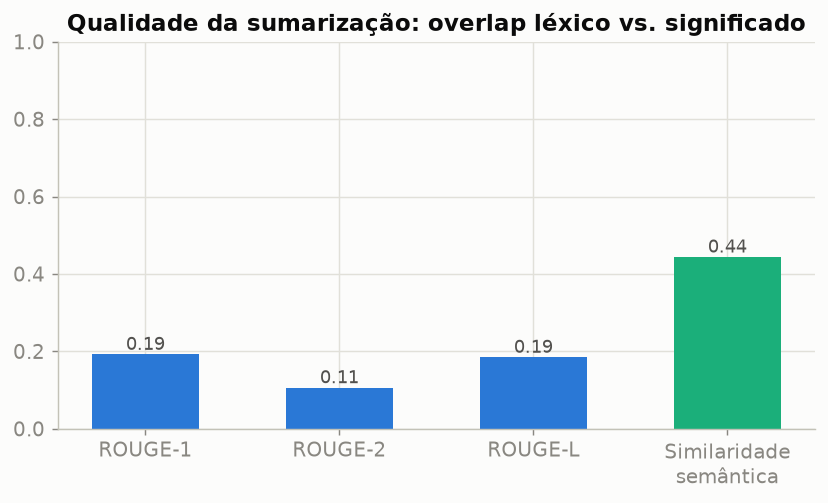

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4))
s = rouge_result["summary"]
metrics_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L", "Similaridade\nsemântica"]
values = [s["rouge1_f_mean"], s["rouge2_f_mean"], s["rougeL_f_mean"], s["semantic_similarity_mean"]]
colors = [C[0], C[0], C[0], C[1]]
bars = ax.bar(metrics_names, values, color=colors, width=0.55)
ax.set_ylim(0, 1)
ax.set_title("Qualidade da sumarização: overlap léxico vs. significado")
for b in bars:
    ax.annotate(f"{b.get_height():.2f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=10, color=viz_style.INK_SECONDARY)
fig.tight_layout()
fig.savefig("../outputs/figures/rouge_sumarizacao.png")
plt.show()

## 2. RAG — precisão@k

Queries de teste com gênero-alvo conhecido: um resultado é "acerto" se o livro
recuperado pertence a um dos gêneros esperados para aquela pergunta.

In [4]:
TEST_QUERIES = [
    {"query": "fantasy books with wizards and magical creatures", "expected_categories": {"Fiction", "Juvenile Fiction"}},
    {"query": "investing and personal finance advice", "expected_categories": {"Business & Economics"}},
    {"query": "christian faith and prayer", "expected_categories": {"Religion"}},
    {"query": "world war two history and soldiers", "expected_categories": {"History"}},
    {"query": "python programming and software development", "expected_categories": {"Computers"}},
    {"query": "recipes and cooking techniques", "expected_categories": {"Cooking"}},
    {"query": "childhood memoir and autobiography", "expected_categories": {"Biography & Autobiography"}},
]

vectorstore = get_vectorstore()
precision_df = metrics.evaluate_rag_precision_at_k(vectorstore, TEST_QUERIES, k=5)
precision_df

C:\Users\Belloni\Documents\Etherys\Desafio A3\notebooks\..\app\rag\chain.py:38: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,query,expected_categories,retrieved_categories,precision_at_5
0,fantasy books with wizards and magical creatures,"Juvenile Fiction, Fiction","Fiction, Juvenile Fiction, Juvenile Fiction, J...",1.0
1,investing and personal finance advice,Business & Economics,"Business & Economics, Business & Economics, Fi...",0.8
2,christian faith and prayer,Religion,"Religion, Religion, Religion, Religion, Religion",1.0
3,world war two history and soldiers,History,"History, History, World War, 1939-1945, Histor...",0.6
4,python programming and software development,Computers,"Computers, gênero não identificado, Computers,...",0.8
5,recipes and cooking techniques,Cooking,"Cooking, Cooking, Cooking, Cooking, Cooking",1.0
6,childhood memoir and autobiography,Biography & Autobiography,"Reference, Biography & Autobiography, gênero n...",0.4


Precisão@5 média: 80.0%


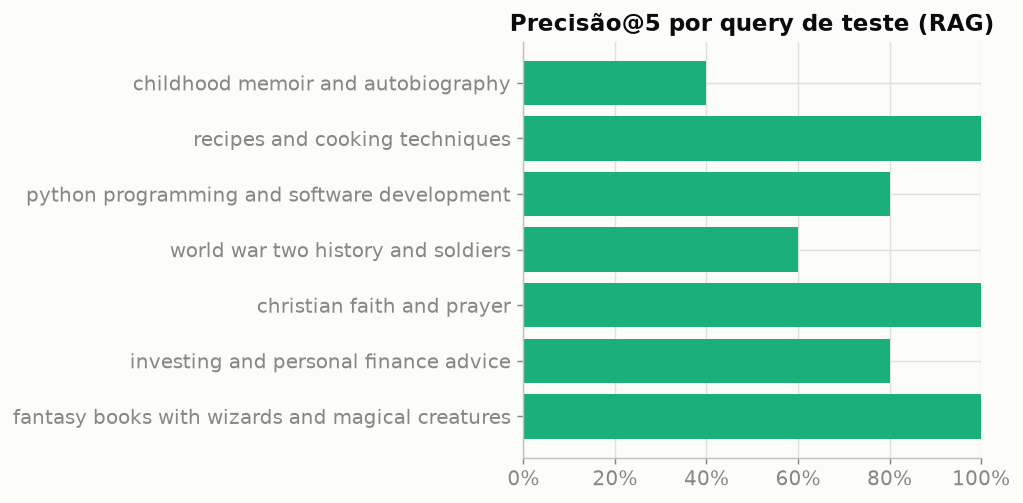

In [5]:
avg_precision = precision_df["precision_at_5"].mean()
print(f"Precisão@5 média: {avg_precision:.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(precision_df["query"], precision_df["precision_at_5"], color=C[1])
ax.set_xlim(0, 1)
ax.set_title("Precisão@5 por query de teste (RAG)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
fig.tight_layout()
fig.savefig("../outputs/figures/rag_precisao_at_k.png")
plt.show()

## 3. Sentimento — VADER vs. LLM (nos casos em que o texto discorda da nota)

Foco nos casos de discrepância (`sentiment_mismatch`), onde o VADER já erra por
definição — é o cenário onde um LLM deveria mostrar vantagem real (sarcasmo,
elogio pontual dentro de crítica, etc.).

In [6]:
sentiment_result = metrics.evaluate_sentiment_vader_vs_llm(df, n_samples=30)
print(sentiment_result["summary"])
sentiment_result["details"].head(8)

{'n_samples': 30, 'vader_accuracy_on_mismatches': np.float64(0.0), 'llm_accuracy_on_mismatches': np.float64(0.6333333333333333)}


,score,score_label,vader_label,llm_label,vader_correct,llm_correct
0,3.0,neutral,negative,neutral,False,True
1,2.0,negative,positive,negative,False,True
2,1.0,negative,positive,negative,False,True
3,5.0,positive,negative,positive,False,True
4,1.0,negative,positive,negative,False,True
5,5.0,positive,negative,positive,False,True
6,3.0,neutral,negative,neutral,False,True
7,4.0,positive,negative,neutral,False,False


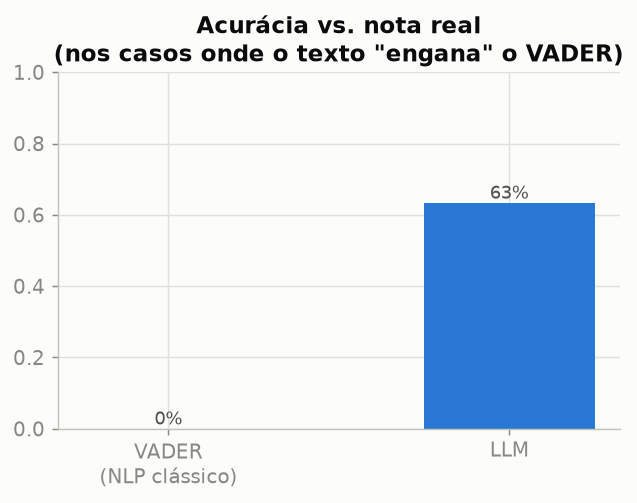

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
s = sentiment_result["summary"]
labels = ["VADER\n(NLP clássico)", "LLM"]
values = [s["vader_accuracy_on_mismatches"], s["llm_accuracy_on_mismatches"]]
bars = ax.bar(labels, values, color=[C[5], C[0]], width=0.5)
ax.set_ylim(0, 1)
ax.set_title("Acurácia vs. nota real\n(nos casos onde o texto \"engana\" o VADER)")
for b in bars:
    ax.annotate(f"{b.get_height():.0%}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=10, color=viz_style.INK_SECONDARY)
fig.tight_layout()
fig.savefig("../outputs/figures/vader_vs_llm_sentimento.png")
plt.show()

## Síntese das métricas

| Frente | Métrica | Resultado |
|---|---|---|
| Sumarização (LLM) | ROUGE-1 / ROUGE-2 / ROUGE-L (F1, vs. resumo humano real) | 0,19 / 0,11 / 0,19 |
| Sumarização (LLM) | Similaridade semântica (cosseno de embeddings, mesmo modelo do RAG) | **0,44** |
| RAG | Precisão@5 média (7 queries de teste, gênero-alvo) | 80% (varia de 40% a 100% por query) |
| Sentimento | Acurácia geral VADER (léxico clássico) vs. nota real | 75,1% (ver `01_eda`/`sentiment.py`) |
| Sentimento | Acurácia nos casos em que o texto "engana" o VADER: VADER vs. LLM | VADER 0% (por construção do subconjunto) vs. **LLM 63,3%** |

**Leituras importantes:**

- **ROUGE moderado é esperado e não é um problema real**: os resumos humanos do
  dataset são "títulos" livres e estilizados (ex.: "Fun, Quick Read", "The
  Rottie"), não resumos de conteúdo — duas pessoas descrevendo a mesma review bem
  raramente escolheriam as mesmas palavras. ROUGE mede *sobreposição de palavras*,
  não significado — por isso penaliza parafraseamento correto.
- **A similaridade semântica (0,44) complementa exatamente esse ponto cego**: em
  vez de contar palavras repetidas, comparamos os embeddings dos dois textos
  (mesmo modelo `all-MiniLM-L6-v2` já usado no RAG — sem precisar de um segundo
  modelo tipo BERTScore). O valor bem mais alto que o ROUGE confirma
  quantitativamente que os resumos gerados capturam o significado das reviews
  mesmo quando escolhem palavras diferentes dos resumos humanos (ex.: real
  "Authentic and biblical" vs. gerado "Heartfelt and Uplifting Christian
  Reflection" — mesma ideia, baixo overlap de palavras, alta similaridade
  semântica). Duas métricas, dois ângulos: léxico e semântico.
- **RAG com 80% de precisão@5 é um resultado sólido para um POC** rodando 100%
  local (embeddings) sem nenhuma etapa de re-ranking — a query mais fraca (childhood
  memoir, 40%) mistura com o gênero "Reference", mostrando espaço de melhoria via
  taxonomia de gêneros mais rica ou re-ranking com LLM.
- **O achado mais forte continua sendo o de sentimento**: no recorte onde o VADER
  (NLP clássico) erra *por definição* (12,5% da amostra total, ver `01_eda.ipynb`),
  o LLM acerta 63,3% das vezes — evidência direta e quantificada de que vale
  investir em LLM para tarefas de linguagem nuançada (sarcasmo, elogio pontual
  dentro de crítica negativa), e não só em léxicos clássicos.
